In [30]:
import pandas as pd
import matplotlib.pyplot as plt


In [31]:
csv_1=pd.read_csv("cleaned_startup(4).csv")

In [32]:
csv_1=pd.read_csv("cleaned_startup(4).csv")
csv_1.head()
csv_1.info()
csv_1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 5000 non-null   int64  
 1   founding_year              5000 non-null   int64  
 2   founders_count             5000 non-null   float64
 3   initial_funding_usd        5000 non-null   float64
 4   total_funding_usd          5000 non-null   float64
 5   revenue_last_year_usd      5000 non-null   float64
 6   employee_count             5000 non-null   float64
 7   burn_rate_usd              5000 non-null   float64
 8   years_operated             5000 non-null   int64  
 9   customer_rating            5000 non-null   float64
 10  status                     5000 non-null   int64  
 11  industry_ai                5000 non-null   bool   
 12  industry_e commerce        5000 non-null   bool   
 13  industry_ecommerce         5000 non-null   bool 

,Unnamed: 0,founding_year,founders_count,initial_funding_usd,total_funding_usd,revenue_last_year_usd,employee_count,burn_rate_usd,years_operated,customer_rating,status,profit_ratio,funding_per_employee
count,5000.000000,5000.000000,5000.00000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2499.500000,2016.452400,2.99440,4.963500e+05,3.770200e+06,3.364218e+06,67.235600,145842.000000,8.151000,3.014400,0.339600,4.976654,3.499595e+05
std,1443.520003,4.052137,1.27636,5.025213e+05,4.356373e+06,4.755358e+06,94.775679,87127.546034,4.343175,0.964572,0.473621,12.767895,7.445801e+05
min,0.000000,2010.000000,1.00000,5.000000e+04,2.000000e+05,0.000000e+00,3.000000,40000.000000,1.000000,1.500000,0.000000,0.000000,6.666667e+02
25%,1249.750000,2013.000000,2.00000,1.000000e+05,1.000000e+06,0.000000e+00,10.000000,90000.000000,4.000000,2.300000,0.000000,0.000000,1.666667e+04
50%,2499.500000,2016.000000,3.00000,3.000000e+05,1.000000e+06,5.349340e+05,25.000000,150000.000000,8.000000,3.000000,0.000000,0.534934,6.666667e+04
75%,3749.250000,2020.000000,4.00000,8.000000e+05,5.000000e+06,7.735979e+06,50.000000,150000.000000,12.000000,3.800000,1.000000,2.674670,2.400000e+05
max,4999.000000,2023.000000,5.00000,1.500000e+06,1.200000e+07,1.160397e+07,300.000000,300000.000000,15.000000,4.500000,1.000000,58.019841,4.000000e+06


In [33]:
csv_1['status'].value_counts()

status
0    3302
1    1698
Name: count, dtype: int64

# FUNDING DISTRIBUTION  

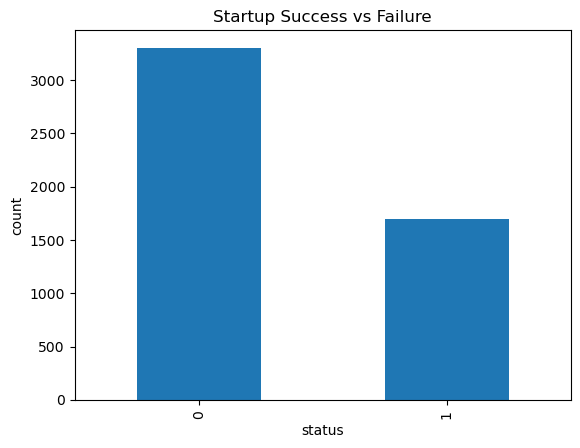

In [34]:
csv_1['status'].value_counts().plot(kind='bar')
plt.title("Startup Success vs Failure")
plt.xlabel("status")
plt.ylabel("count")
plt.show()

# REVENUE DISTRIBUTION

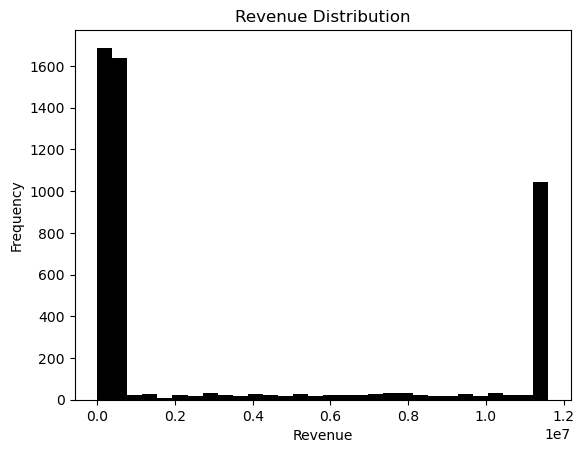

In [35]:
plt.hist(csv_1['revenue_last_year_usd'],bins=30,color='black')
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# COUNTRY DISTRIBUTION

In [36]:
country_cols=[col for col in csv_1.columns if 'country_' in col]
country_distribution=csv_1[country_cols].sum()


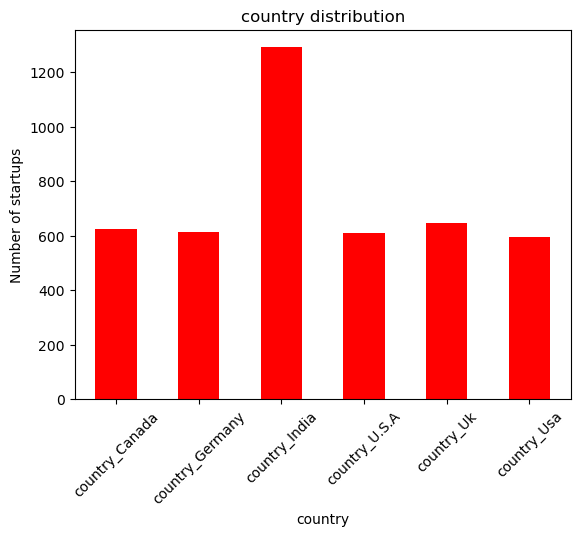

In [37]:
country_distribution.plot(kind='bar',color='red')
plt.title('country distribution')
plt.xlabel('country')
plt.ylabel('Number of startups')
plt.xticks(rotation=45)
plt.show()

# Industry_wise Startup count

In [38]:
industry_cols=[col for col in csv_1.columns if 'industry_' in col]
industry_distribution=csv_1[industry_cols].sum()

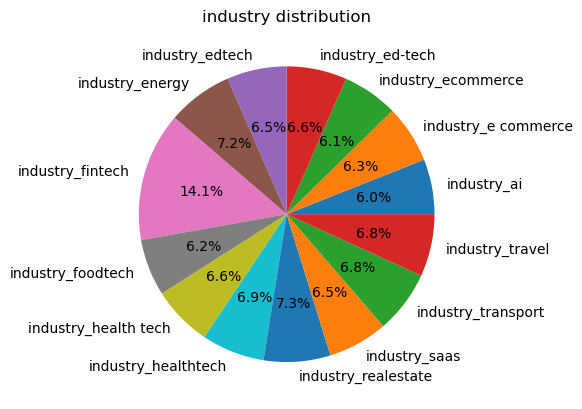

In [39]:
industry_distribution.plot(kind='pie',autopct='%1.1f%%')
plt.title('industry distribution')
plt.show()

# Founding year trend

<Axes: title={'center': 'Startup Founded per year'}, xlabel='founding year', ylabel='Number of Startups'>

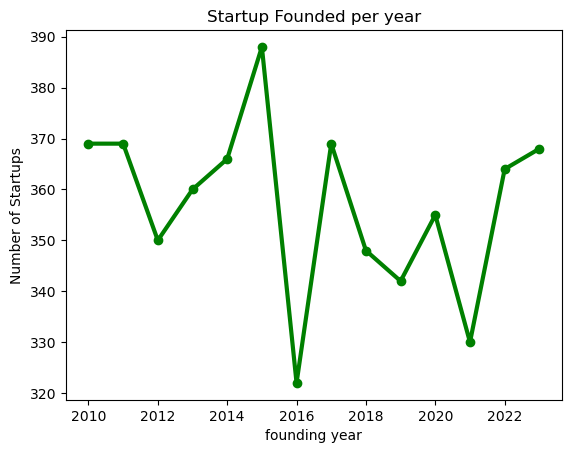

In [40]:
years_count=csv_1['founding_year'].value_counts().sort_index()
years_count.plot(kind='line',
                 color='green',
                 linewidth=3,
                 marker='o',
                 title='Startup Founded per year',
                 xlabel='founding year',
                 ylabel='Number of Startups')

Text(0.5, 0, 'Number of Startups')

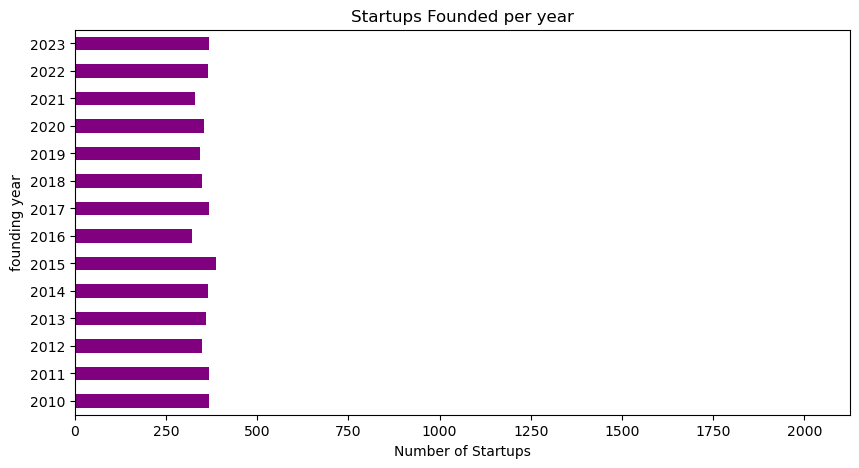

In [41]:
years_count=csv_1['founding_year'].value_counts().sort_index()
ax=years_count.plot(kind='barh',figsize=(10,5),color='purple')
years_count.plot(
        kind='line',
        marker='o',
        lw=3,
        ax=ax,
)
ax.set_title('Startups Founded per year')
ax.set_ylabel("founding year")
ax.set_xlabel('Number of Startups')

<Axes: title={'center': 'Burn Rate vs Total Funding'}, xlabel='total_funding_usd', ylabel='burn_rate_usd'>

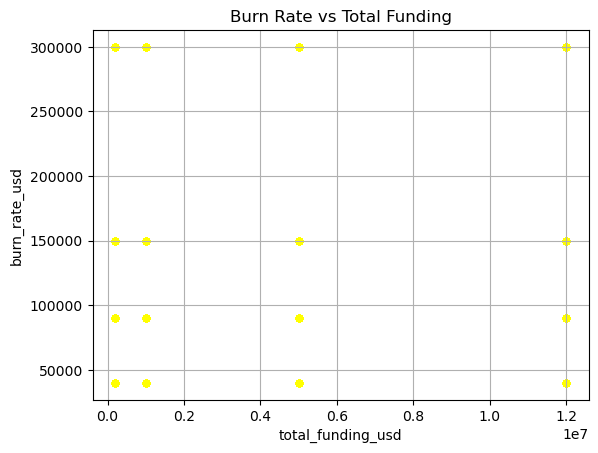

In [44]:

csv_1.plot(
    kind='scatter',
    x='total_funding_usd',
    y='burn_rate_usd',
    alpha=0.5,
    grid=True,
    title='Burn Rate vs Total Funding',
    color='yellow'
)

<Axes: title={'center': 'Employee count vs Revenue'}, xlabel='employee_count', ylabel='revenue_last_year_usd'>

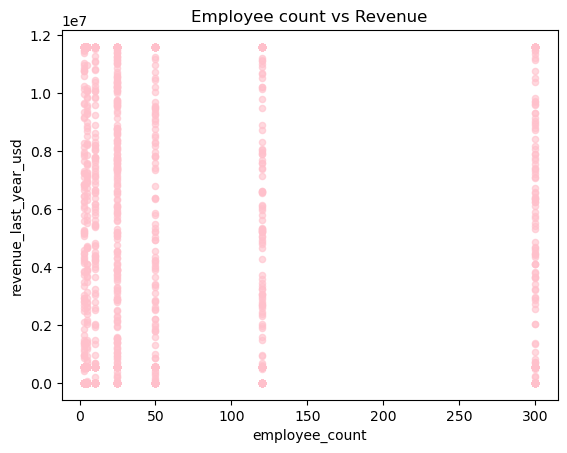

In [45]:
csv_1.plot(kind='scatter',
           x='employee_count',
           y='revenue_last_year_usd',
           alpha=0.6,
           title="Employee count vs Revenue",
           color='pink'
           )

<Axes: title={'center': 'revenue_last_year_usd'}, xlabel='status'>

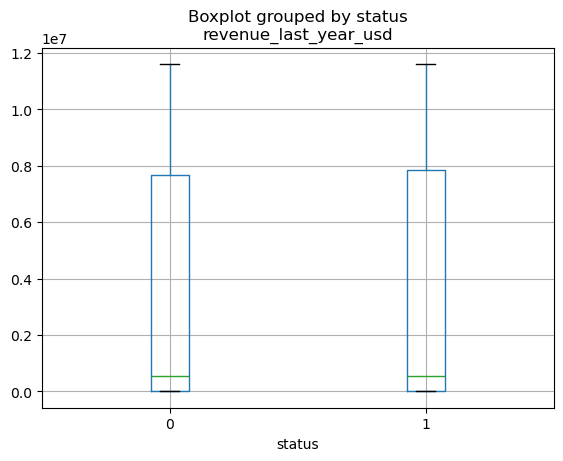

In [46]:
csv_1.boxplot(column='revenue_last_year_usd',by='status')

# Bubble plot

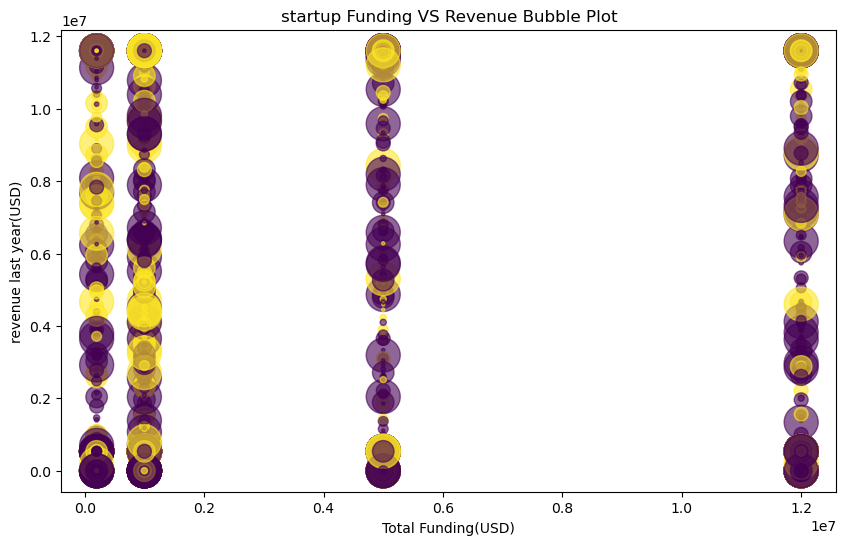

In [47]:
colors=csv_1['status'].astype('category').cat.codes
plt.figure(figsize=(10,6))
plt.scatter(
    csv_1['total_funding_usd'],
    csv_1['revenue_last_year_usd'],
    s=csv_1['employee_count']*2,
    c=colors,
    alpha=0.6
)

plt.xlabel('Total Funding(USD)')
plt.ylabel("revenue last year(USD)")
plt.title("startup Funding VS Revenue Bubble Plot")
plt.show()

# Wordcloud

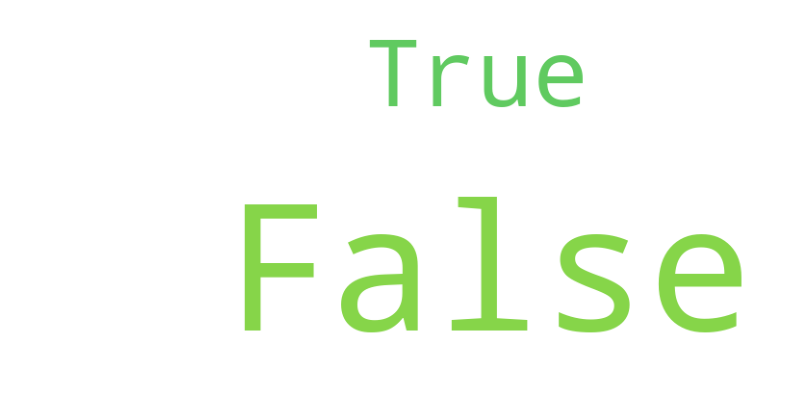

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text= " ".join(csv_1['industry_ecommerce'].dropna().astype(str)
)
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Seaborn

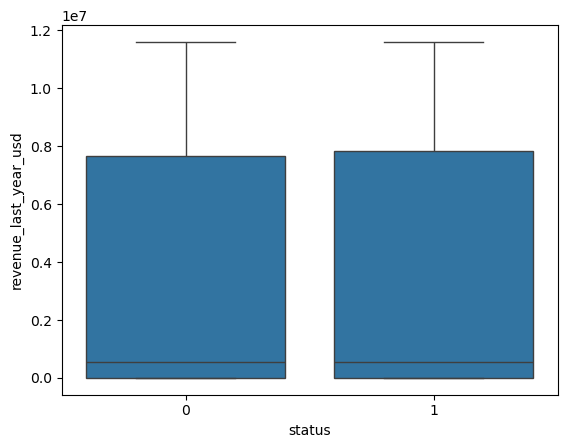

In [49]:
import seaborn as sns
sns.boxplot(x='status',
            y='revenue_last_year_usd',data=csv_1)
plt.show()

# Regression plot

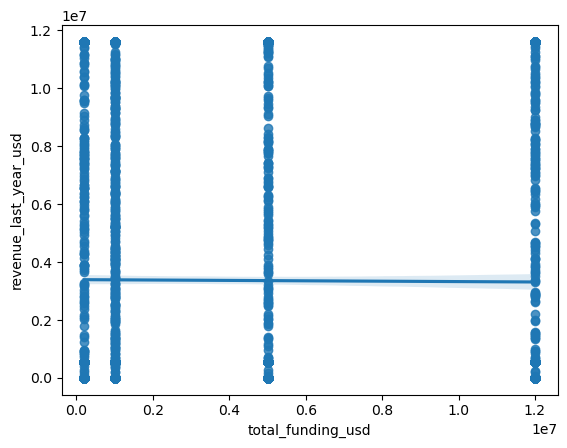

In [50]:
sns.regplot(x='total_funding_usd',
            y='revenue_last_year_usd',data=csv_1)
plt.show()

# Heatmap

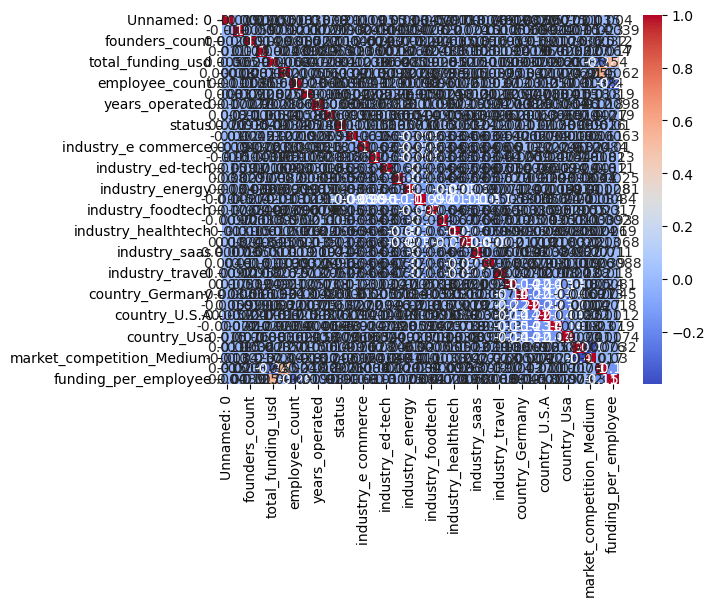

In [51]:
corr=csv_1.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()



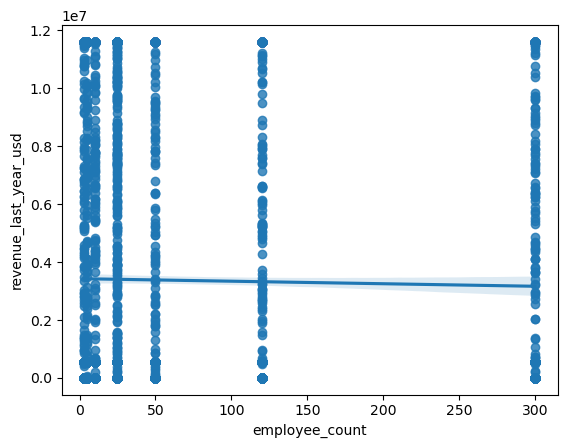

In [52]:
sns.regplot(x='employee_count',y='revenue_last_year_usd',data=csv_1)
plt.show()

<Axes: title={'center': 'Number of Startupd Founded Per year'}, xlabel='founding_year'>

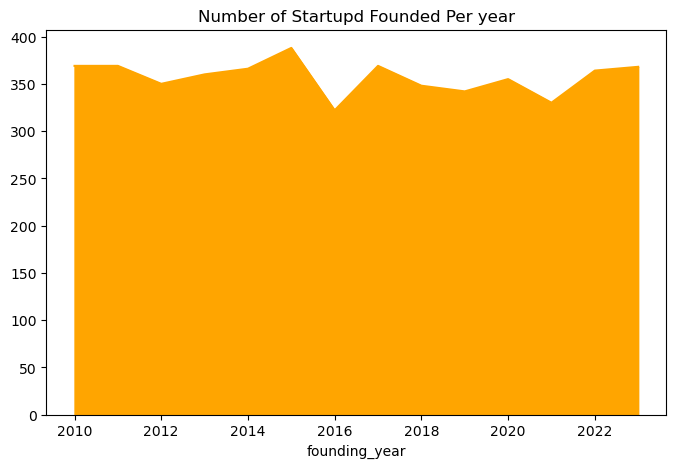

In [53]:
csv_1['founding_year'].value_counts().sort_index().plot.area(title="Number of Startupd Founded Per year",
figsize=(8,5),color='orange'
)

In [ ]:
csv_1['country']=csv_1[['country_Canada','country_Germany', 'country_India', 'country_U.S.A', 'country_Uk']].idxmax(axis=1)
csv_1['country']=csv_1['country'].str.replace("country_",'')
csv_1['country'].unique()


array(['Canada', 'India', 'U.S.A', 'Uk', 'Germany'], dtype=object)

In [30]:
import plotly.express as px

fig=px.scatter_geo(
    csv_1,
    locations='country',
    locationmode='country names',
    size='total_funding_usd',
    title='Startup Funding by country'
)
fig.show()

/tmp/ipykernel_3115/713582015.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig=px.scatter_geo(
